# Time Series Forecasting — Modeling & Evaluation

## Objectives

In this notebook I will train and evaluate two models on the processed data from `02_feature_engineering.ipynb`: I will use a naive baseline (`lag_1`-as-prediction, `lag_52`-as-prediction) as a floor, Linear Regression as an interpretable baseline, and Random Forest to capture non-linear relationships such as holiday proximity effects/interactions between context variables. 

Performance is evaluated using weighted mean absolute error (WMAE) instead of plain MAE/RMSE to deal with holiday-week business stakes, where weight = 5 if the week is a holiday week, 1 otherwise. 

## Output
- Trained Linear Regression and Random Forest models
- Recommended model with performance metrics
- Justification for model choice and buisness relevance
- Visualizations for README

## 3.1 Setup & Imports
Importing libraries (`numpy`, `pandas`, `matplotlib`, `seaborn`, `sklearn`) for plotting, modeling, and evaluation, and setting absolute paths for reproducibility. Imported `sklearn`'s `mean_absolute_error` since it has a `sample_weight` argument which is needed for WMAE evaluation 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# modeling
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

# evaluation 
from sklearn.metrics import mean_absolute_error

RANDOM_STATE = 42
TRAIN = '../data/processed/train.csv'
TEST = '../data/processed/test.csv'

## 3.2 Load Processed Data 
Loading the processed train/test datasets saved in `02_feature_engineering.ipynb`, and re-casting datetime dtypes. Handles the X/y split by dropping both `Weekly_Sales_log`/`Weekly_Sales` for `X_train`/`X_test`, and defining separate `y_train` by model. Additionally I drop `Date` from `X_train/test`, since raw datetime isn't directly usable by the models (its useful signal is captured through engineered calendar and lag features) resulting in an error. `Date` is retained in `train_df`/`test_df` for later residual-over-time analysis.

Linear regression additionally requires its own `X_train_LR`/`X_test_LR`: raw `MarkDown1-5`, `Unemployment`, `Month`, `Week`, `lag_1`, and `lag_52` are dropped in favor of their `_log`/cyclical counterparts to avoid near-redundant, highly correlated feature pairs that destabilize OLS coefficients, and the remaining features are standardized with `StandardScaler` (fit on train, applied to both sets) since OLS is sensitive to features on very different scales. Random forest uses the full, unscaled feature set, since tree splits are threshold-based per feature and unaffected by both correlation and scale.

In [2]:
train_df = pd.read_csv(TRAIN)
test_df = pd.read_csv(TEST)

train_df['Date'] = pd.to_datetime(train_df['Date'])
test_df['Date'] = pd.to_datetime(test_df['Date'])

print(train_df['Date'].dtype, train_df['Date'].dtype)

datetime64[us] datetime64[us]


Confirm dtype is not string/object

In [3]:
X_train = train_df.drop(columns=['Weekly_Sales_log', 'Weekly_Sales', 'Date'])
X_test = test_df.drop(columns=['Weekly_Sales_log', 'Weekly_Sales', 'Date'])
y_test = test_df['Weekly_Sales']

# linear regression
LR_drop_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5',
                 'Unemployment', 'Month', 'Week', 'lag_1', 'lag_52']
X_train_LR = X_train.drop(columns=LR_drop_cols)
X_test_LR = X_test.drop(columns=LR_drop_cols)
y_train_log = train_df['Weekly_Sales_log']

scaler = StandardScaler()
X_train_LR_scaled = scaler.fit_transform(X_train_LR)
X_test_LR_scaled = scaler.transform(X_test_LR)

# random forest
y_train_raw = train_df['Weekly_Sales']

In [4]:
X_train.shape, X_test.shape, y_test.shape, y_train_log.shape, y_train_raw.shape, X_train_LR.shape, X_test_LR.shape

((136342, 38),
 (124741, 38),
 (124741,),
 (136342,),
 (136342,),
 (136342, 28),
 (124741, 28))

`.shape` output confirms the train and test X/y were defined correctly — `X_train/test`/`y_test` having 136342/124741 rows and 38 columns for `train`, `y_train_log/raw` also have the correct row counts. The (136342, 28) and (124741, 28) for `X_train_LR`/`X_test_LR` confirms they were defined correctly. 

## 3.3 Naive Baselines 
I use a naive baseline of `lag_1/52`-as-predictions as a floor to compare the downstream linear and non-linear models. To do this I compare the WMAE of `X_test` of `lag_1/52` with `y_test` (sample weight set using `np.where`, 5 if true, 1 otherwise). 

In [5]:
weight = np.where(X_test['IsHoliday'], 5, 1)
WMAE_lag_1 = mean_absolute_error(y_test, X_test['lag_1'],sample_weight = weight)
WMAE_lag_52 = mean_absolute_error(y_test, X_test['lag_52'],sample_weight = weight)

print(f"WMAE (lag_1 baseline): {WMAE_lag_1}")
print(f"WMAE (lag_52 baseline): {WMAE_lag_52}")

WMAE (lag_1 baseline): 1800.2473974954214
WMAE (lag_52 baseline): 1891.4855952936084


`lag_1` scored better (lower error) than `lag_52` (~1800.25 vs. ~1891.49). This makes sense: `lag_1` captures short-term momentum, while `lag_52` is a noisier signal, since a full year allows economic conditions, store-level changes, and pricing to drift between the two comparison points. This suggests week-to-week momentum drives this data more reliably than year-over-year seasonality, and sets `lag_1` (WMAE ~= 1800.25) as the stronger naive floor — meaning downstream models should be evaluated against this bar, not just against `lag_52`.

## 3.4 Baseline: Linear Regression (on `Weekly_Sales_log`)

I will fit the baseline Linear Regression model on `X_train_log` and `y_train_log`, since the skew would effect linear modeling, then after predicting, before computing WMAE I will inverse-transform the values to the original raw values using the following operation: `np.style(x) * np.expm1(abs(x))`. Lasty, I will compare the WMAE against the naive floor (`lag_1`, WMAE ~= 1800.25), and `lag_52` as a secondary reference. 

In [6]:
lr = LinearRegression()
lr.fit(X_train_LR, y_train_log)
y_pred_lr = lr.predict(X_test_LR)
inv = np.sign(y_pred_lr) * np.expm1(abs(y_pred_lr))

# evaluate
LR_WMAE = mean_absolute_error(y_test, inv, sample_weight=weight)
print(f"WMAE (LR): {LR_WMAE}")

WMAE (LR): 2761.9572349348773


The WMAE for LR is larger than WMAE for both the naive baselines `lag_1`/`lag_52` (~2761.96 vs. ~1800.25/~1891.49). A likely explanation for this is that `Weekly_Sales` is driven by recent, week-by-week momentum with possibly nonlinear structure that the linear model can't capture. Whether this model can be recommend will be decided later. 

### 3.4.2 Coefficient Inspection

Since `X_train_LR` was standardized with `StandardScaler`, coefficient magnitudes are directly comparable across features, so I extract `lr.coef_`, pair each value with its feature name, and sort by absolute magnitude to see which features the model weighted most heavily. Unlike random forest's feature importance, a coefficient gives both direction and relative magnitude of a feature's effect.

In [7]:
coefs = pd.DataFrame({
    'features':  X_train_LR.columns, 
    'coefficients': lr.coef_
})
coefs['abs_coefficients'] = coefs['coefficients'].abs()
coefs = coefs.sort_values(by='abs_coefficients', ascending=False, ignore_index=True)
coefs.head(10)

,features,coefficients,abs_coefficients
0,lag_1_log,0.772386,0.772386
1,lag_52_log,0.215421,0.215421
2,Week_cos,0.124094,0.124094
3,MarkDown2_No_Promotion,-0.109233,0.109233
4,Month_cos,-0.062423,0.062423
5,IsHoliday,-0.061457,0.061457
6,MarkDown4_No_Promotion,-0.047917,0.047917
7,MarkDown3_No_Promotion,-0.043420,0.043420
8,MarkDown2_log,-0.034740,0.034740
9,MarkDown1_No_Promotion,-0.030708,0.030708


The highest coefficient is `lag_1_log` (~0.77), significantly higher than the second highest, `lag_52_log` (~0.22), supporting the earlier assumption that `Weekly_Sales` is driven more by previous-week momentum than year-over-year seasonality. `IsHoliday` has a small negative coefficient (~-0.06), which makes sense since the engineered features `days_until_holiday`/`days_since_holiday` likely capture the holiday effect more precisely, making `IsHoliday` a redundant, weaker signal. Four of the `MarkDown*_No_Promotion` features appear in the top 10, each with small negative coefficients (`MarkDown2_No_Promotion` (~-0.11), `MarkDown4_No_Promotion` (~-0.05), `MarkDown3_No_Promotion` (~-0.04), `MarkDown1_No_Promotion` (~-0.03)). Since these flags are 1 when no promotion ran, a negative coefficient means the absence of a promotion is associated with lower predicted sales — meaning promotions are associated with higher sales, as expected. Some correlation likely remains among untouched features, so these coefficients should be read as directionally suggestive rather than precise, isolated effects.

## 3.5 Random Forest (on `Weekly_Sales`)

Since the linear regression model performed worse than the naive baseline, likely because it can't capture nonlinear relationships between features, I fit a random forest model on `X_train` and `y_train_raw`, since tree splits aren't sensitive to feature scale or correlation the way OLS coefficients are, then after predicting I compute WMAE directly — theres no need to inverse.

In [8]:
rf = RandomForestRegressor(random_state=RANDOM_STATE)
rf.fit(X_train, y_train_raw)
y_pred_rf = rf.predict(X_test)

# evaluate
RF_WMAE = mean_absolute_error(y_test, y_pred_rf, sample_weight=weight)
print(f"WMAE (RF): {RF_WMAE}")

WMAE (RF): 1492.7022221728876


The random forest model performed significantly better than both naive baselines and linear regression (~1492.70 vs. ~1800.25/~2761.96), which is a ~17.06% improvement over the `lag_1` floor. This supports the 3.4 hypothesis that nonlinear interactions exist between features that linear regression can't capture. Its important to note however that this model uses default hyperparameters with no tuning, due to a compressed scope I put on this project to prioritize other projects — this result reflects whether a nonlinear model helps at all, not an optimized ceiling. 

### 3.5.2 Feature Importance

Using random forest's `feature_importances_` attribute to rank features by their contribution to reducing Gini impurity across all trees, to see which features are important and which might just be noise. 

In [14]:
feature_importance = pd.DataFrame({
    'Features': X_train.columns,
    'Importance': rf.feature_importances_
})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False, ignore_index=True)
feature_importance.index += 1
feature_importance


,Features,Importance
1,lag_52_log,0.436055
2,lag_52,0.396822
3,lag_1,0.076745
4,lag_1_log,0.072205
5,Dept,0.002104
6,Fuel_Price,0.001430
7,Week_sin,0.001414
8,CPI,0.001232
9,Temperature,0.001220
10,Size,0.001115


The lag features are the dominant features with `lag_52_log`/`lag_52` having a combined importance of ~84%  — `lag_1`/`lag_1_log` have a combined importance of ~14.9%. The raw lag features' importance need to be combined with their log transformed versions since they are essentially two copies of the same real signal. The lag features are significantly larger than the other features with the next highest importance feature being `Dept` with an importance of only ~0.21% — meaning everything else is negligible. 

The combined importance of `lag_52_log`/`lag_52`  being much higher than `lag_1`/`lag_1_log` (~84% vs. ~14.9%) might seem to be contradictory to what was seen with the LR and naive baseline models where the coefficient was higher for `lag_1_log` than `lag_52_log`(~0.77 vs. ~0.22), and WMAE for `lag_1` baseline naive was lower than `lag_52` at (~1800.25 vs. ~1891.49). 

However, this difference can be explained by LR and the naive baseline using single, isolated features to predict — in which case `lag_1` alone beats out `lag_52` alone since previous week's value is a more decent standalone predictor, while the week's previous year value is a noisier predictor due to economic drift and other external factors. In RF, `lag_52` isn't used alone — it's used in combination with other features like `days_until_holiday` and `CPI`, which may correct for its noisiness.

With lag features being so dominant, every other engineered feature — holiday proximity, calendar encoding, markdowns, store context — contributes comparatively little, suggesting RF's predictive power is driven almost entirely by recent sales history rather than the broader feature set. 

## 3.6 Residual Analysis Over Time

Because WMAE produces a number that is one aggregate value across the test rows, it doesn't show when the model struggles — the model could be uniformly mediocre everywhere, or excellent the majority of the time and terrible for a couple of important weeks. 

To get better insight into how well the model actually performed, I will plot residuals against `Date` to see whether errors cluster around specific time periods — I will look specifically for holiday weeks since I explicitly engineered that feature and WMAE weights 5x for holidays. Looking at holiday weeks specifically is also critical for the business — holiday sales swings are larger and getting them wrong are costlier. 

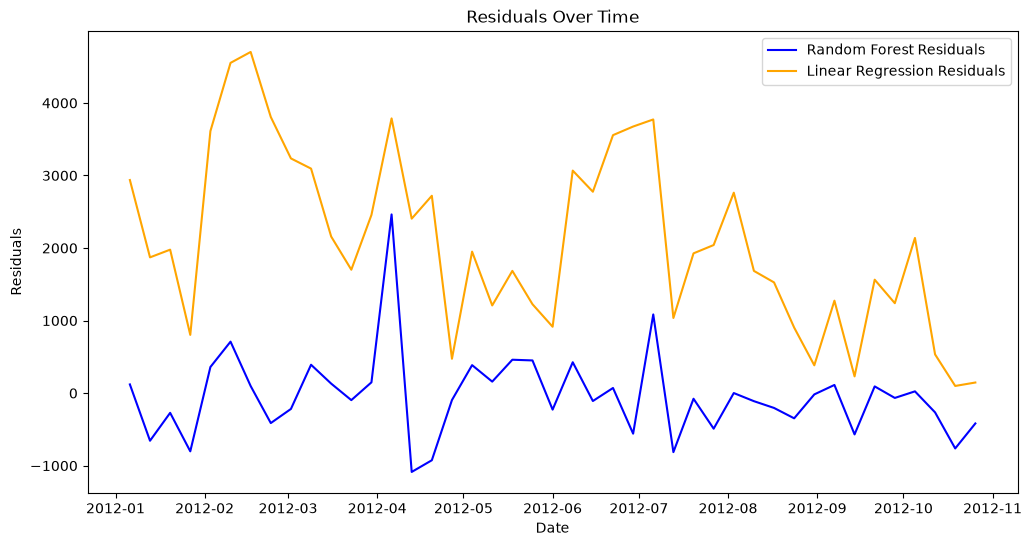

In [10]:
residuals_df = pd.DataFrame({
    'Date': test_df['Date'],
    'residuals_rf': y_test - y_pred_rf,
    'residuals_lr': y_test - inv
})

plt.figure(figsize=(12, 6))

plt.plot(residuals_df.groupby('Date')['residuals_rf'].mean(), label='Random Forest Residuals', color='blue')
plt.plot(residuals_df.groupby('Date')['residuals_lr'].mean(), label='Linear Regression Residuals', color='orange')

plt.title('Residuals Over Time')
plt.xlabel('Date')
plt.ylabel('Residuals')
plt.legend()

plt.savefig('../images/residuals_over_time.png')
plt.show()

Looking at the overall plot, the residuals for LR across the entire `Date` range are above 0 and in the higher range of residuals, meaning the model under predicts sales often and more extreme. RF's residuals, on the other hand, are small and roughly balanced around zero for most of the range (roughly -1000 to 700), aside from the two spikes noted below, slightly under/over-predicting sales. The consistent zigzag pattern across both models suggests a common external driver of error that's not specific to either model. 

For both plots there are no major spikes during any of the specified holidays, but there are two spikes that are shared between both models: ~`2012-04`(LR: ~3900/RF: ~2500) and ~`2012-07`(LR: ~3900/RF: ~1000). Neither of these spikes fall on a flagged holiday `Date`. The largest spike for RF, and second largest for LR, falls near `2012-04`. The likely explanation for what is driving this error is that either an event like Easter or July 4th, during those months is affecting shopping behavior, but is not flagged in the dataset as holidays, so the features I engineered simply can't capture that effect, or it is a data quality issue or a specific `Store`/`Dept` anomaly getting averaged. This evidence doesn't support my previous assumption where I expected to see errors clustered around holidays.


## 3.7 Segmentation Analysis 

The previous residual analysis showed when the errors occurred in the model over time, but it revealed that the errors do not cluster on specific holiday dates. Therefore to further understand how the models actually perform, I will run segmentation analysis, segmenting by `Type` to see where errors occur — whether they are evenly spread across `Store`s/`Dept`s, or concentrated in specific groups. To do this I will use the type features I one-hot encoded during feature engineering and compute their WMAE for each type, for both RF and LR predictions. 

In [10]:
# labeling store types 
store_types = pd.Series('Other', index=X_test.index)
store_types[(X_test['Type_B'] == 0) & (X_test['Type_C'] == 0)] = 'Type A'
store_types[(X_test['Type_B'] == 1)] = 'Type B'
store_types[(X_test['Type_C'] == 1)] = 'Type C'

# Compute WMAE for each type 
for t in ['Type A', 'Type B', 'Type C']:
    mask = store_types == t
    print(f"WMAE RF ({t})")
    print(mean_absolute_error(y_test[mask], y_pred_rf[mask], sample_weight=weight[mask]))
    print(f"WMAE LR ({t})")
    print(mean_absolute_error(y_test[mask], inv[mask], sample_weight=weight[mask]))



WMAE RF (Type A)
1785.1665593869782
WMAE LR (Type A)
3514.166202984226
WMAE RF (Type B)
1297.1634860187598
WMAE LR (Type B)
2180.1553443675402
WMAE RF (Type C)
755.2962263414964
WMAE LR (Type C)
1173.4428014014675


For every store type, RF has lower error than LR as expected: `Type A` RF: ~1785.17 vs. LR: ~3514.17, `Type B` RF: ~1297.16 vs. LR: 2180.16, `Type C`: RF ~755.30 vs. 1173.44. Both models performed the best for `Type C` stores, and even though `C` had the lowest count found during EDA (`A`:22 `B`:17 `C`:6), since WMAE is an average, the difference in count alone doesn't explain the difference in error. A likely explanation for the difference in error between the store types is store `Size`: `Type A/B` tend to have larger sizes, adding more complex, volatile sales patterns that are inherently harder to predict than smaller `Type C` stores — while this size-type relationship is not specifically tested in this analysis, verifying it would be a next step/limitation.
 
The segmentation findings appear to have some conflict with what was found earlier in feature importance where `Type_B/C` had near zero importance (~0.0001). Despite `Type` having extremely low importance in RF's splits, the performance varying meaningfully by segment suggests the effect of store type on sales is likely indirectly captured through other features like `Size` or `lag` values that reflect a store's typical scale. 

RF continues to be the stronger model as it holds up far better across all store types than LR. 

## 3.8 Model Comparison

For model comparison I created a table with the name of the model, WMAE, and the percent change from the naive baseline `lag_1` floor.

| Model | WMAE | % Change vs. `lag_1` Floor |
|---|---|---|
| `lag_1` (naive baseline) | ~1800.25 | — (floor) |
| `lag_52` (naive baseline) | ~1891.49 | +5.07% (worse) |
| Linear Regression | ~2761.96 | +53.42% (worse) |
| Random Forest | ~1492.70 | -17.08% (better) |

This shows the best model for predicting weekly sales for this dataset is random forest model, achieving a WMAE of ~1492.70 (roughly 17.1% lower than the naive `lag_1` floor) and the only model to beat `lag_1` floor.  

## 3.9 Recommended Model & Limitations/Next Steps

The final recommended model is **random forest**, since it was the only model that beat the naive baseline `lag_1` floor WMAE (~1492.70 vs. ~1800.25), and held up across type segments better than linear regression. 

The uneven `Thanksgiving` lift across `Type`/`Dept` found in EDA combined with findings in residual analysis over time (the error spikes did not align with flagged holidays suggesting an external driver of error), and segmentation analysis (error also uneven across store types, likely due to `Size`) directly answer the research question posed in EDA: "is the holiday effect uniform across the business, or concentrated in specific `Store`/`Dept` segments?". These findings provide evidence that shows holiday effect is not uniform across the business, but rather, **concentrated in segments** in this dataset. 

### Limitations:

- No hyperparameter tuning
- Unflagged real-world events (Easter/July 4th) holiday features can't capture
- `Size`/`Type` correlation untested
- Temporal split limitation (only one full Nov/Dec cycle in the dataset)
- Multicollinearity in LR's coefficients not fully resolved. 

### Next Steps:
- Tune RF hyperparameters
- Test `Size`/`Type` correlation directly
- Engineer unflagged holidays feature
- Applying gradient boosted model (XGBoost/LightGBM)